In [1]:
import matplotlib as mpl
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def generate_barplots_single_metric(
    datasets: list,
    mode: str,
    method_colors: dict,
    data_dir: str,
    height: float = 0.4,
    alpha: float = 0.5,
    save: bool = True,
    output_path: str = "combined_scores_plot.png",
    scale_metric: bool = False,
    subplot_width: float = 1.0,
    rank_subplot_width: float = 0.8,   # width for the rank column
    title_fontsize: int = 7,
    row_fontsize: int = 8,
    data_rename_dict: dict = None,
    method_rename_dict: dict = None,
    pointsize: int = 2,
    bg_color: str = '#e0e0e0',
    rank_cmap: mpl.colors.Colormap = None,   # optional: custom rank colormap
):
    """
    Plot ONE metric across multiple datasets in a single figure with horizontal bars,
    and a rightmost 'Mean rank' column (colored squares with rank numbers).
    The entire bar plot region (including any spacing) is white; other areas use `bg_color`.

    Args:
        datasets (list): Dataset names.
        mode (str): One of "Directional_Consistency", "Temporal_Precision",
                    "Negative_Control_Robustness", "simulation1", or "simulation2".
        method_colors (dict): {method_name: color}.
        data_dir (str): Base directory where dataset folders are located.
        height (float): Bar height.
        alpha (float): Bar alpha.
        save (bool): Whether to save the plot.
        output_path (str): Save path when save=True.
        scale_metric (bool): If True, apply (score + 1) / 2 to all scores.
        subplot_width (float): Width for each dataset subplot.
        rank_subplot_width (float): Width for the rank column.
        title_fontsize (int): Font size for dataset titles.
        row_fontsize (int): Font size for y-tick (method) labels.
        data_rename_dict (dict): Mapping original dataset names -> display names.
        method_rename_dict (dict): Mapping original method names -> display names.
        pointsize (int): Size of scatter points (per-fold scores).
        bg_color (str): Background color outside the white bar region.
        rank_cmap (mpl.colors.Colormap): Colormap for rank squares (default: viridis).
    """
    # ---------------- Checks ----------------
    if not datasets:
        raise ValueError("Dataset list cannot be empty.")
    if not method_colors:
        raise ValueError("Method colors dictionary cannot be empty.")
    if mode not in [
        "Directional_Consistency_CBDir",
        "Directional_Consistency_ICVCoh",
        "Temporal_Precision",
        "Negative_Control_Robustness",
        "simulation1",
        "simulation2",
    ]:
        raise ValueError(
            "Mode must be one of 'Directional_Consistency', 'Temporal_Precision', "
            "'Negative_Control_Robustness', 'simulation1', or 'simulation2'."
        )

    # --------------- Helper(s) ---------------
    def get_contrasting_color(rgb):
        # Simple luminance-based contrast: return black/white text for colored squares
        if isinstance(rgb, (tuple, list)) and len(rgb) >= 3:
            r, g, b = rgb[:3]
        else:
            r, g, b, *_ = mpl.colors.to_rgba(rgb)
        luminance = 0.299 * r + 0.587 * g + 0.114 * b
        return "black" if luminance > 0.6 else "white"

    if rank_cmap is None:
        rank_cmap = plt.cm.coolwarm

    # --------------- Decide which file to load for the single metric ---------------
    def metric_path_for_mode(base_dir: Path, dataset: str) -> Path:
        if mode == "Directional_Consistency_CBDir":
            # Previously: CBDir and ICVCoh. Choose CBDir as the single metric by default.
            return base_dir / dataset /  "cbdir_df.csv"
        elif mode == "Directional_Consistency_ICVCoh":
            # Previously: CBDir and ICVCoh. Choose CBDir as the single metric by default.
            return base_dir / dataset /  "icvcoh_df.csv"
        elif mode == "Temporal_Precision":
            # Previously: CTO and Spearman. Choose Spearman.
            return base_dir / dataset /  "spearman_df.csv"
        elif mode == "Negative_Control_Robustness":
            # Previously: self_transition and normalized_entropy. Choose self_transition.
            return base_dir / dataset /  "self_transition_df.csv"
        elif mode == "simulation1":
            # Previously: cosine_similarity and pearson. Choose cosine_similarity.
            return base_dir / dataset /  "cosine_similarity_df.csv"
        elif mode == "simulation2":
            # Previously: distance_correlation and pearson. Choose distance_correlation.
            return base_dir / dataset / "distance_correlation_df.csv"
        else:
            raise ValueError("Invalid mode.")

    # --------------- Load data & collect methods ---------------
    base_dir = Path(data_dir)
    metric_dfs = {}
    all_methods = set()

    for dataset in datasets:
        mpath = metric_path_for_mode(base_dir, dataset)
        if not mpath.exists():
            raise FileNotFoundError(f"{mpath} not found.")
        df = pd.read_csv(mpath)
        # Ensure numeric
        df.iloc[:, 1:] = df.iloc[:, 1:].astype(np.float64)
        metric_dfs[dataset] = df
        all_methods.update(df["Method"].tolist())

    all_methods = sorted(list(all_methods))

    # --------------- Names & colors ---------------
    if method_rename_dict is None:
        method_rename_dict = {}
    display_methods = [method_rename_dict.get(m, m) for m in all_methods]

    # updated_colors = {
    #     method_rename_dict.get(m, m): method_colors.get(m, "#999999") for m in all_methods
    # }
    # method_colors = updated_colors

    # --------------- Theme ---------------
    sns.set_theme(style="white")

    # --------------- Figure & layout ---------------
    n_datasets = len(datasets)
    # We have `n_datasets` dataset columns + 1 rank column
    n_cols = n_datasets + 1
    rank_index = n_datasets
    width_ratios = [
        (rank_subplot_width if i == rank_index else subplot_width) for i in range(n_cols)
    ]
    total_fig_width = sum(width_ratios)

    fig, axes = plt.subplots(
        1,
        n_cols,
        figsize=(total_fig_width, 5),
        gridspec_kw={"wspace": 0.1, "hspace": 0.1, "width_ratios": width_ratios},
    )
    if n_cols == 1:
        axes = [axes]  # normalize list for single-col case
    fig.patch.set_facecolor(bg_color)

    # White bar region band
    bar_region_left, bar_region_right = 0.1, 0.9
    bar_region_bottom, bar_region_top = 0.1, 0.9
    fig.add_artist(
        Rectangle(
            (bar_region_left, bar_region_bottom),
            bar_region_right - bar_region_left,
            bar_region_top - bar_region_bottom,
            transform=fig.transFigure,
            facecolor="white",
            edgecolor="none",
            zorder=-1,
        )
    )
    for ax in axes:
        for side in ("top", "right", "bottom", "left"):
            ax.spines[side].set_visible(False)
        ax.set_facecolor("white")

    # --------------- Compute per-dataset means/stds and raw scores ---------------
    metric_means = {m: [] for m in all_methods}
    metric_stds  = {m: [] for m in all_methods}
    metric_scores = {m: [] for m in all_methods}

    for j, dataset in enumerate(datasets):
        df = metric_dfs[dataset]
        for method in all_methods:
            if method in df["Method"].values:
                vals = df[df["Method"] == method].iloc[0, 1:].to_numpy()
                if scale_metric:
                    vals = (vals + 1) / 2
                metric_scores[method].append(vals)
                metric_means[method].append(vals.mean())
                # ddof=1 if >=2 folds; handle single-fold safely:
                ddof = 1 if vals.size >= 2 else 0
                metric_stds[method].append(vals.std(ddof=ddof))
            else:
                # method not present for this dataset
                metric_scores[method].append(np.full(1, np.nan))
                metric_means[method].append(np.nan)
                metric_stds[method].append(np.nan)

    # --------------- Mean across datasets & ranks ---------------
    mean_of_means = {m: np.nanmean(metric_means[m]) for m in all_methods}
    rank_series = pd.Series(mean_of_means).rank(ascending=False, method="min")
    ranks = rank_series.astype(int).to_dict()

    # Reorder methods by rank (best first or last?). Keeping your previous reverse=True behavior:
    all_methods = sorted(all_methods, key=lambda x: ranks.get(x, np.inf), reverse=True)
    display_methods = [method_rename_dict.get(m, m) for m in all_methods]
    method_to_color_sorted = {
        method: method_colors.get(method, "#999999")
        for method in all_methods
    }

    # Rank coloring
    max_rank_val = max(ranks.values()) if len(ranks) else 1
    rank_norm = mpl.colors.Normalize(vmin=1, vmax=max_rank_val)

    def rank_color(rank: int):
        return rank_cmap(rank_norm(rank))

    # --------------- Draw dataset columns ---------------
    for j in range(n_datasets):
        ax = axes[j]
        for i, method in enumerate(all_methods):
            mu = metric_means[method][j]
            if not np.isnan(mu):
                ax.barh(
                    i,
                    mu,
                    color=method_to_color_sorted.get(method, "#999999"),
                    height=height,
                    alpha=alpha,
                    edgecolor="none",
                )
                # ax.errorbar(
                #     mu,
                #     i,
                #     xerr=metric_stds[method][j],
                #     fmt="none",
                #     ecolor="black",
                #     capsize=3,
                #     capthick=1,
                #     elinewidth=1,
                # )
                scores = metric_scores[method][j]
                ax.scatter(
                    scores,
                    np.full_like(scores, i),
                    color="black",
                    s=pointsize,
                    alpha=0.8,
                    zorder=10,
                    marker="o",
                    facecolors=None,
                    edgecolors="black",
                )
        ax.set_ylim(-0.5, len(all_methods) - 0.5)
        if j == 0:
            ax.set_yticks(range(len(all_methods)))
            ax.set_yticklabels(display_methods, fontsize=row_fontsize)
        else:
            ax.set_yticks([])
        title_text = data_rename_dict.get(datasets[j], datasets[j]) if data_rename_dict else datasets[j]
        ax.set_title(title_text, fontsize=title_fontsize)
        ax.set_xticks([])

    # --------------- Draw Mean rank column ---------------
    ax_rank = axes[rank_index]
    for i, method in enumerate(all_methods):
        r = ranks[method]
        # color = rank_color(r)
        color = method_to_color_sorted[method]
        ax_rank.add_patch(
            patches.FancyBboxPatch(
                (0.42, i - 0.3),
                0.16,
                0.6,
                boxstyle="square,pad=0",
                facecolor=color,
                edgecolor="none",
            )
        )
        ax_rank.text(
            0.5,
            i,
            str(r),
            ha="center",
            va="center",
            fontsize=5,
            color = 'white'
            # color=get_contrasting_color(color),
        )
    ax_rank.set_xlim(0, 1)
    ax_rank.set_ylim(-0.5, len(all_methods) - 0.5)
    ax_rank.set_yticks([])
    ax_rank.set_title("Mean rank", fontsize=title_fontsize)
    ax_rank.set_xticks([])
    ax_rank.axis("off")

    # --------------- Layout tweaks ---------------
    fig.subplots_adjust(
        left=bar_region_left,
        right=bar_region_right,
        bottom=bar_region_bottom,
        top=bar_region_top,
    )

    # --------------- Save / show ---------------
    if save:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()

In [2]:
import numpy as np

method_colors = {
    'velocyto': "#6587AB",
    'scvelo_dyn': "#76B7B2",
    'scvelo_stc': "#92CB8A",
    'veloae': "#F6A24F",
    'dynamo_m1': "#DC6F71",
    'pyrovelocity_m1': "#006e54",
    'pyrovelocity_m2': "#a7e6d7",
    'unitvelo_uni': "#aa4c8f",
    'unitvelo_ind': "#E9B6DA",
    'velovae_std': "#C6A11B",
    'velovae_fullvb': "#FBEBB2",
    'kvelo': "#FAAEA0",
    'celldancer': "#7ABBEF",
    'velovi': "#A4AB47",
    'latentvelo_std': "#C4D6A0",
    'sctour_mse': "#4d5aaf",
    'sctour_nb': "#8491c3",
    'sctour_zinb': "#bbc8e6",
    'deepvelo': "#D2660D",
    'sdevelo': "#22808B",
    'svelvetvae': "#F6D55C",
    'cell2fate': "#AD2513",
    'tivelo_std': "#333631",
    'tivelo_simple': "#AFB39F",
    'graphvelo_std': "#8D6262"
}

In [3]:
methods = ['velocyto','scvelo_dyn','scvelo_stc','veloae','dynamo_m1','unitvelo_ind','unitvelo_uni',
           'velovae_std','velovae_fullvb','deepvelo','celldancer',
           'pyrovelocity_m1','pyrovelocity_m2','kvelo','velovi','sdevelo','cell2fate','svelvetvae',
            'latentvelo_atac', 'latentvelo_std', 'tivelo_std', 'tivelo_simple', 'sctour_mse',
           'sctour_nb', 'sctour_zinb', 'multivelo', 'graphvelo_std', 'graphvelo_atac']

method_rename_dict = {
        'velocyto': "Velocyto",
        'scvelo_dyn': "scVelo (dyn)",
        'scvelo_stc': "scVelo (stc)",
        'veloae': "VeloAE",
        'dynamo_m1': "Dynamo (m1)",
        'unitvelo_ind': "UniTVelo (ind)",
        'unitvelo_uni': "UniTVelo (uni)",
        'velovae_std': "VeloVAE (std)",
        'velovae_fullvb': "VeloVAE (Full VB)",
        'deepvelo': "DeepVelo",
        'celldancer': "cellDancer",
        'pyrovelocity_m1': "Pyro-Velocity (m1)",
        'pyrovelocity_m2': "Pyro-Velocity (m2)",
        'kvelo': "  -velo",
        'velovi': "veloVI",
        'cell2fate': "cell2fate",
        'sdevelo': "SDEvelo",
        'svelvetvae': "SvelvetVAE",
        'latentvelo_std': "LatentVelo (std)",
        'latentvelo_atac': "LatentVelo (ATAC)",
        'tivelo_std': "TIVelo (std)",
        'tivelo_simple': "TIVelo (simple)",
        'sctour_mse': "scTour (MSE)",
        'sctour_nb': "scTour (NB)",
        'sctour_zinb': "scTour (ZINB)",
        'multivelo': "MultiVelo",
        'graphvelo_std': "GraphVelo (std)",
        'graphvelo_atac': "GraphVelo (ATAC)"}

In [4]:
highlight_method_colors = {method: "#E2B49D" for method in methods}
highlight_method_colors.update({
    'latentvelo_std': method_colors['latentvelo_std'],
    'sctour_zinb': method_colors['sctour_zinb'],
    'sctour_nb': method_colors['sctour_nb'],
    'sctour_mse': method_colors['sctour_mse'],
})

In [5]:
datasets = ["data05", "data06"]
generate_barplots_single_metric(datasets, 
                        "Directional_Consistency_CBDir",
                        highlight_method_colors,
                        subplot_width=1,
                        scale_metric=True,
                        title_fontsize=7,
                        row_fontsize=6,
                        pointsize=1,
                        data_dir="./", 
                        data_rename_dict={
                            "data05": "Data 05",
                            "data06": "Data 06"
                        },
                        method_rename_dict=method_rename_dict,
                        alpha = 1.0,
                        save= True,
                        output_path="batch_CBDir_rank_highlight.svg")

In [6]:
datasets = ["data05", "data06"]
generate_barplots_single_metric(datasets, 
                        "Directional_Consistency_ICVCoh",
                        highlight_method_colors,
                        subplot_width=1,
                        scale_metric=True,
                        title_fontsize=7,
                        row_fontsize=6,
                        pointsize=1,
                        data_dir="./", 
                        data_rename_dict={
                            "data05": "Data 05",
                            "data06": "Data 06"
                        },
                        method_rename_dict=method_rename_dict,
                        alpha = 1.0,
                        save= True,
                        output_path="batch_ICVCoh_rank_highlight.svg")

In [7]:
batch_datasets = ["data05", "data06"]
single_datasets = ["data05_1", "data05_2", "data05_3", "data05_4", "data06_1", "data06_2"]
direction_metric_files = {
    "CBDir": "cbdir_df.csv",
    "ICVCoh": "icvcoh_df.csv",
}

def compute_direction_rank_df(datasets, rank_col_name):
    direction_metrics = {}
    for metric_name, filename in direction_metric_files.items():
        metric_parts = []
        for dataset in datasets:
            metric_df = pd.read_csv(Path(dataset) / filename)
            fold_cols = metric_df.columns[1:]
            metric_long = metric_df.melt(
                id_vars="Method",
                value_vars=fold_cols,
                var_name="fold",
                value_name="score",
            )
            metric_parts.append(metric_long[["Method", "score"]])
        direction_metrics[metric_name] = (
            pd.concat(metric_parts, ignore_index=True)
            .groupby("Method", as_index=True)["score"]
            .mean()
        )

    rank_df = pd.DataFrame(direction_metrics).reset_index()
    metric_rank_cols = []
    for metric_name in direction_metric_files:
        metric_rank_col = f"{metric_name}_rank"
        metric_rank_cols.append(metric_rank_col)
        rank_df[metric_rank_col] = rank_df[metric_name].rank(
            ascending=False,
            method="min",
        )

    rank_df["rank_mean"] = rank_df[metric_rank_cols].mean(axis=1)
    rank_df[rank_col_name] = rank_df["rank_mean"].rank(
        ascending=True,
        method="min",
    )
    return rank_df.sort_values(rank_col_name).reset_index(drop=True)

batch_direction_rank_df = compute_direction_rank_df(batch_datasets, "batch_rank")
single_direction_rank_df = compute_direction_rank_df(single_datasets, "single_rank")

batch_summary_df = batch_direction_rank_df.rename(
    columns={
        "CBDir": "batch_CBDir",
        "ICVCoh": "batch_ICVCoh",
        "CBDir_rank": "batch_CBDir_rank",
        "ICVCoh_rank": "batch_ICVCoh_rank",
        "rank_mean": "batch_rank_mean",
    }
)[["Method", "batch_CBDir", "batch_ICVCoh", "batch_CBDir_rank", "batch_ICVCoh_rank", "batch_rank_mean", "batch_rank"]]

single_summary_df = single_direction_rank_df.rename(
    columns={
        "CBDir": "single_CBDir",
        "ICVCoh": "single_ICVCoh",
        "CBDir_rank": "single_CBDir_rank",
        "ICVCoh_rank": "single_ICVCoh_rank",
        "rank_mean": "single_rank_mean",
    }
)[["Method", "single_CBDir", "single_ICVCoh", "single_CBDir_rank", "single_ICVCoh_rank", "single_rank_mean", "single_rank"]]

scatter_df = (
    batch_summary_df
    .merge(single_summary_df, on="Method", how="inner")
    .sort_values(["batch_rank", "single_rank"])
    .reset_index(drop=True)
)

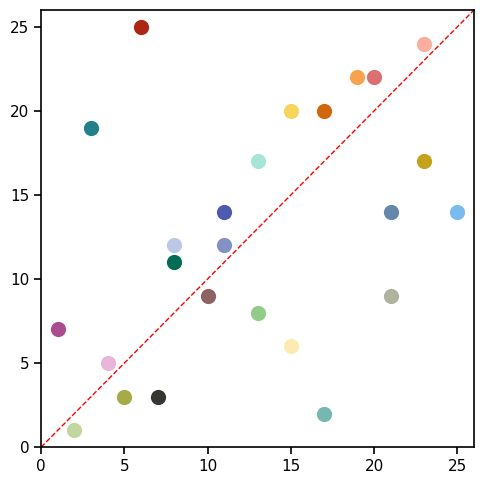

,Method,batch_CBDir,batch_ICVCoh,batch_CBDir_rank,batch_ICVCoh_rank,batch_rank_mean,batch_rank,single_CBDir,single_ICVCoh,single_CBDir_rank,single_ICVCoh_rank,single_rank_mean,single_rank
0,unitvelo_uni,0.499595,0.899029,1.0,1.0,1.0,1.0,0.140121,0.868770,19.0,2.0,10.5,7.0
1,latentvelo_std,0.281865,0.888852,6.0,2.0,4.0,2.0,0.401040,0.877814,8.0,1.0,4.5,1.0
2,sdevelo,0.342897,0.779128,2.0,10.0,6.0,3.0,-0.018099,0.824275,22.0,9.0,15.5,19.0
3,unitvelo_ind,0.281277,0.781183,7.0,9.0,8.0,4.0,0.397743,0.826645,9.0,8.0,8.5,5.0
4,velovi,0.268961,0.799323,9.0,8.0,8.5,5.0,0.471744,0.802256,2.0,13.0,7.5,3.0
5,cell2fate,0.292625,0.752325,5.0,14.0,9.5,6.0,0.029062,0.484354,20.0,25.0,22.5,25.0
6,tivelo_std,0.296098,0.729945,4.0,16.0,10.0,7.0,0.467796,0.803888,3.0,12.0,7.5,3.0
7,pyrovelocity_m1,0.254129,0.769948,10.0,12.0,11.0,8.0,0.254362,0.819181,16.0,10.0,13.0,11.0
8,sctour_zinb,0.183289,0.821069,17.0,5.0,11.0,8.0,-0.038722,0.846123,23.0,4.0,13.5,12.0
9,graphvelo_std,0.339968,0.659670,3.0,20.0,11.5,10.0,0.465776,0.721448,4.0,20.0,12.0,9.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")


def style_axis(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.2)

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=5,
        width=1.2,
        colors="black",
        bottom=True,
        top=False,
        left=True,
        right=False,
    )


fig, ax = plt.subplots(figsize=(5, 5))

for _, row in scatter_df.iterrows():
    method = row["Method"]
    ax.scatter(
        row["batch_rank"],
        row["single_rank"],
        s=120,
        color=method_colors.get(method, "#4c4c4c"),
        linewidth=0,
        zorder=3,
    )

lims = [
    scatter_df[["batch_rank", "single_rank"]].to_numpy().min(),
    scatter_df[["batch_rank", "single_rank"]].to_numpy().max(),
]

tick_start = np.floor(lims[0]) - 1
tick_end = np.ceil(lims[1]) + 1

x_ticks = np.arange(tick_start, tick_end + 1, 5)
y_ticks = np.arange(tick_start, tick_end + 1, 5)

ax.plot(
    [tick_start, tick_end],
    [tick_start, tick_end],
    linestyle="--",
    color="red",
    linewidth=1,
    zorder=1,
)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xlim(tick_start, tick_end)
ax.set_ylim(tick_start, tick_end)

# ax.set_xlabel("Batch rank")
# ax.set_ylabel("Single rank")

style_axis(ax)
plt.tight_layout()
plt.savefig("batch_single_direction_rank_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

scatter_df

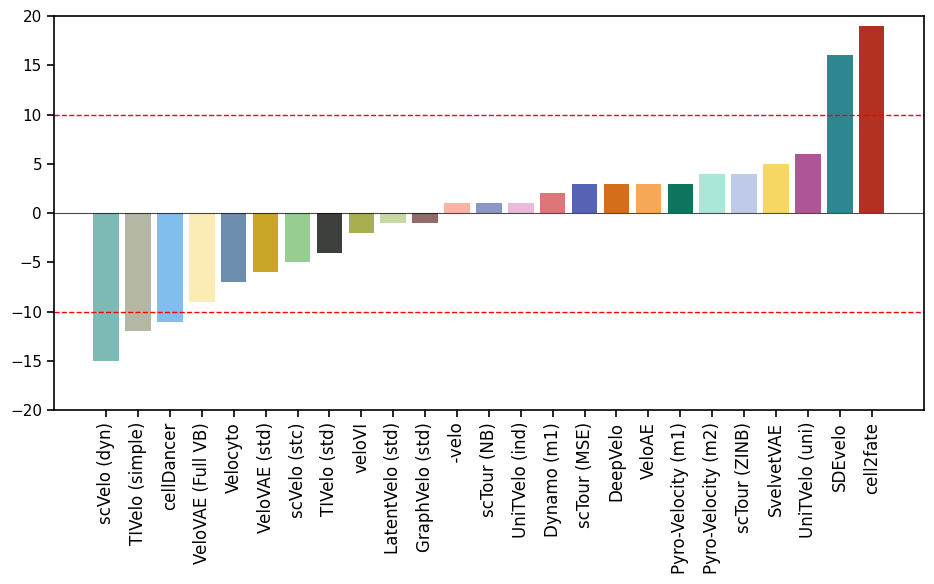

,Method,batch_rank,single_rank,rank_diff
0,scvelo_dyn,17.0,2.0,-15.0
1,tivelo_simple,21.0,9.0,-12.0
2,celldancer,25.0,14.0,-11.0
3,velovae_fullvb,15.0,6.0,-9.0
4,velocyto,21.0,14.0,-7.0
5,velovae_std,23.0,17.0,-6.0
6,scvelo_stc,13.0,8.0,-5.0
7,tivelo_std,7.0,3.0,-4.0
8,velovi,5.0,3.0,-2.0
9,latentvelo_std,2.0,1.0,-1.0


In [9]:
rank_diff_df = scatter_df.copy()
rank_diff_df["rank_diff"] = rank_diff_df["single_rank"] - rank_diff_df["batch_rank"]
rank_diff_df = rank_diff_df.sort_values("rank_diff").reset_index(drop=True)
rank_diff_df["Method_label"] = rank_diff_df["Method"].map(lambda x: method_rename_dict.get(x, x))

fig_width = max(8, 0.38 * len(rank_diff_df))
fig, ax = plt.subplots(figsize=(fig_width, 6))

ax.bar(
    rank_diff_df["Method_label"],
    rank_diff_df["rank_diff"],
    color=[method_colors.get(method, "#4c4c4c") for method in rank_diff_df["Method"]],
    edgecolor="none",
    alpha=0.95,
)

ax.axhline(-10, linestyle="--", color="red", linewidth=1)
ax.axhline(10, linestyle="--", color="red", linewidth=1)
ax.axhline(0, linestyle="-", color="black", linewidth=0.8, alpha=0.7)

max_abs_diff = max(10, np.ceil(np.abs(rank_diff_df["rank_diff"]).max()))
y_limit = max_abs_diff + 1
ax.set_ylim(-y_limit, y_limit)
ax.set_xlabel("")
# ax.set_ylabel("Single rank - Batch rank")
ax.tick_params(axis="x", labelrotation=90, labelsize=12)

style_axis(ax)
plt.tight_layout()
plt.savefig("batch_single_rank_diff_bar.png", bbox_inches="tight", dpi=150)
plt.show()

rank_diff_df[["Method", "batch_rank", "single_rank", "rank_diff"]]